##Step 1 - Installing the packages

In [51]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mustafatayyipbayram/ppe-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ppe-detection' dataset.
Path to dataset files: /kaggle/input/ppe-detection


In [52]:
!pip install ultralytics

##Step 2 - Importing all the libraries

In [53]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.7/112.6 GB disk)


In [54]:
from ultralytics import YOLO
from IPython.display import Image

#### Add your Roboflow API Key to Colab Secrets

To securely use your Roboflow API Key without exposing it directly in your notebook, follow these steps:

1.  Click the "🔑 Secrets" icon in the left sidebar of your Colab notebook.
2.  Click "+ New secret".
3.  For the **Name**, type `ROBOFLOW_API_KEY`.
4.  For the **Value**, paste your actual Roboflow API Key.
5.  Ensure the "Notebook access" toggle is turned **ON** for this secret.

Once added, the code below will be able to access your API key securely.

In [55]:
!pip install roboflow

from roboflow import Roboflow
from google.colab import userdata # Import userdata to access Colab secrets

# Retrieve API key from Colab Secrets
api_key = userdata.get("ROBOFLOW_API_KEY")

# Check if API key was retrieved successfully
if api_key is None:
    raise ValueError("ROBOFLOW_API_KEY not found in Colab Secrets. Please add it as instructed above.")

rf = Roboflow(api_key=api_key)

project = rf.workspace("roboflow-universe-projects").project("safety-vests")

version = project.version(14)

dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [56]:
dataset.location

'/content/Safety-Vests-14'

In [57]:
model = YOLO('yolo11n.pt')
model.train(data=f"{dataset.location}/data.yaml", epochs=10, imgsz=640)

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Safety-Vests-14/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d5bcdfe06b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

To determine the correct path to `data.yaml`, let's list the contents of the downloaded dataset directory.

In [58]:
import os
print(f"Listing contents of: {dataset.location}")
!ls -F "{dataset.location}"

Listing contents of: /content/Safety-Vests-14
data.yaml  README.dataset.txt  README.roboflow.txt  test/  train/  valid/


In [59]:
Image(r"/content/runs/detect/train2/confusion_matrix.png", width= 800)

FileNotFoundError: No such file or directory: '/content/runs/detect/train2/confusion_matrix.png'

FileNotFoundError: No such file or directory: '/content/runs/detect/train2/confusion_matrix.png'

<IPython.core.display.Image object>

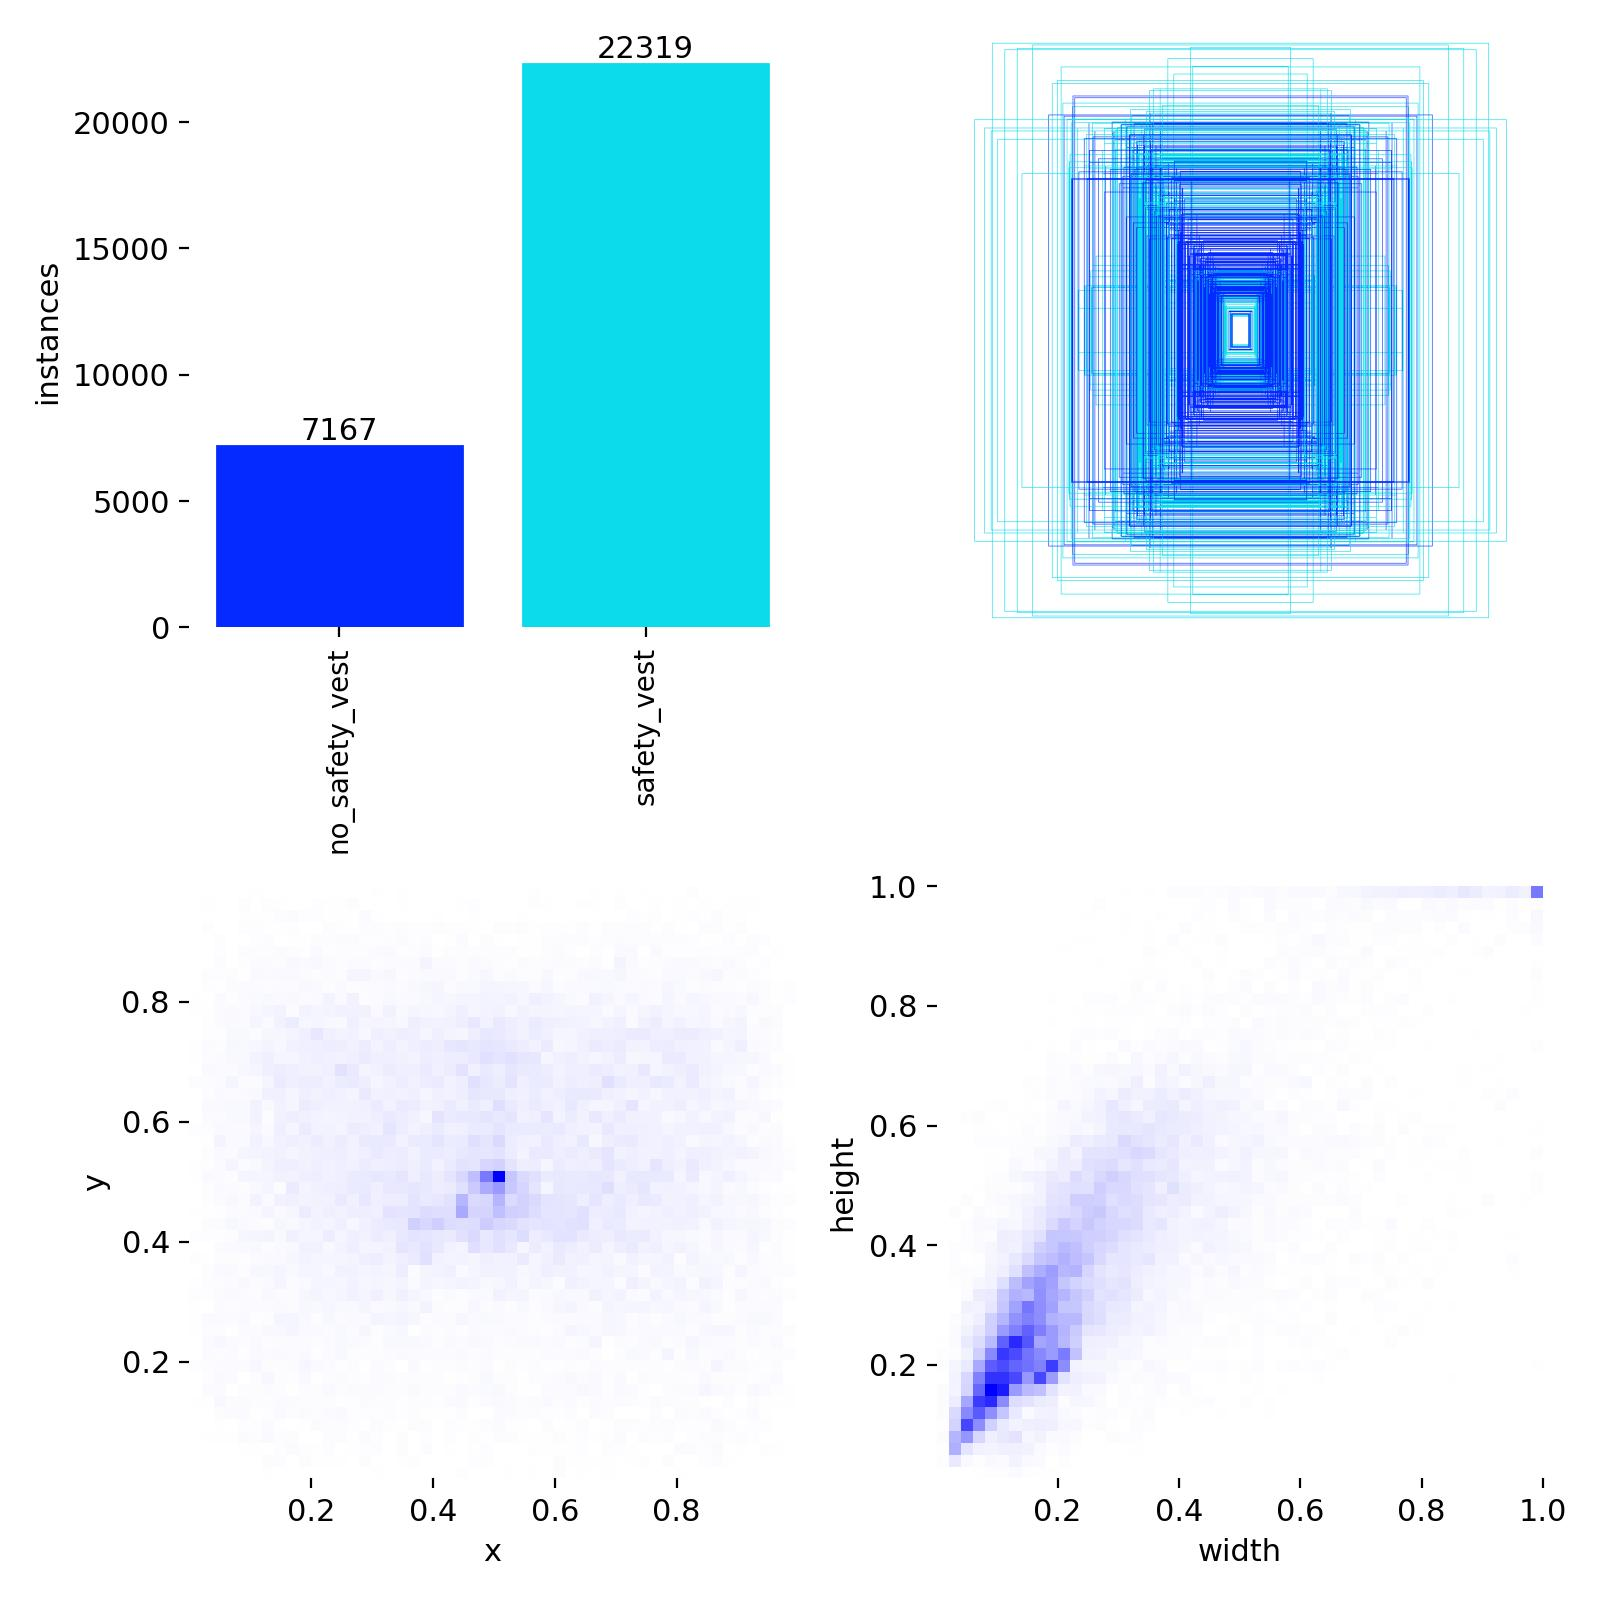

In [60]:
Image(r"/content/runs/detect/train2/labels.jpg", width=600)

In [61]:
Image("/content/runs/detect/train2/results.png", width=1000)

FileNotFoundError: No such file or directory: '/content/runs/detect/train2/results.png'

FileNotFoundError: No such file or directory: '/content/runs/detect/train2/results.png'

<IPython.core.display.Image object>

In [62]:
!yolo task=detect mode=val model="/content/runs/detect/train2/weights/best.pt" data="/content/Safety-Vests-14/data.yaml"

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1314.2±324.9 MB/s, size: 51.6 KB)
val: Scanning /content/Safety-Vests-14/valid/labels.cache... 779 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 779/779 105.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 49/49 4.3it/s 11.3s
                   all        779       1648      0.833      0.767      0.841      0.487
        no_safety_vest        189        361       0.83      0.762      0.823      0.427
           safety_vest        609       1287      0.837      0.773      0.859      0.547
Speed: 2.0ms preprocess, 4.6ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [63]:
!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" conf=0.25 source="/content/Safety-Vests-14/test/images" save=True

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

image 1/390 /content/Safety-Vests-14/test/images/000135_jpg.rf.dfa27899df8c30d344176f756f14c362.jpg: 640x640 4 no_safety_vests, 1 safety_vest, 10.9ms
image 2/390 /content/Safety-Vests-14/test/images/00345_jpg.rf.980f296b6b3ae23cf3c0bfd7ace54498.jpg: 640x640 1 no_safety_vest, 1 safety_vest, 7.8ms
image 3/390 /content/Safety-Vests-14/test/images/00372_jpg.rf.6d93e1c4178ec8acd1894bd03acffdbb.jpg: 640x640 2 no_safety_vests, 2 safety_vests, 8.1ms
image 4/390 /content/Safety-Vests-14/test/images/00411_jpg.rf.6d5f81c48b1f78ad6c1707012d059bcc.jpg: 640x640 1 no_safety_vest, 2 safety_vests, 7.3ms
image 5/390 /content/Safety-Vests-14/test/images/00446_jpg.rf.880cdf65a4b7abb7dfa6252e9601a0ce.jpg: 640x640 8 safety_vests, 7.4ms
image 6/390 /content/Safety-Vests-14/test/images/00541_jpg.rf.ec64ca1c553bc94208828dd32bf92b46.jpg: 640x640 4

##Display Prediction Results

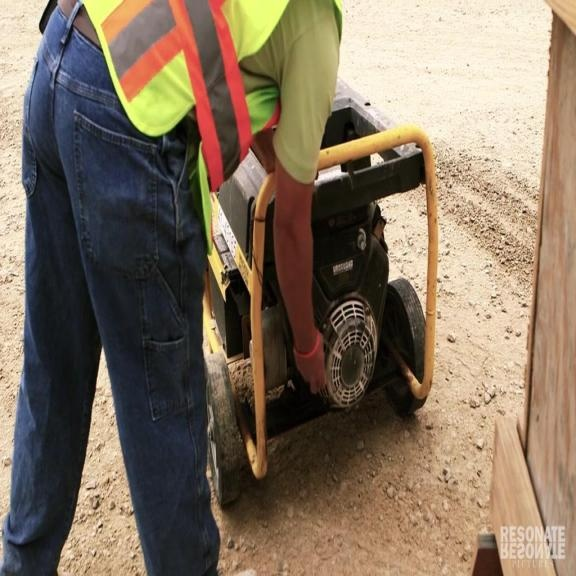

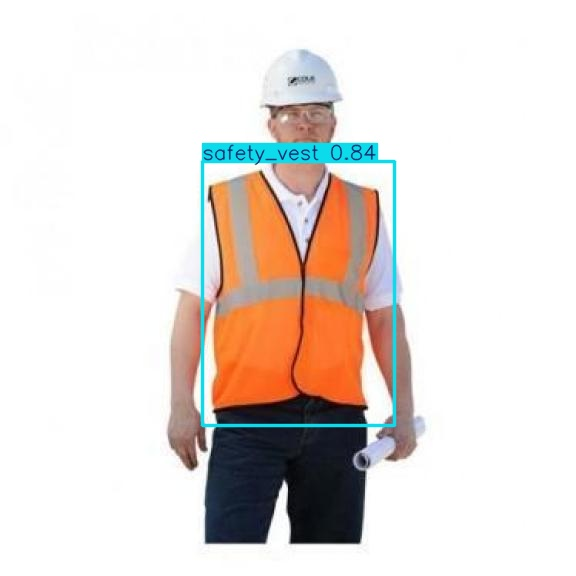

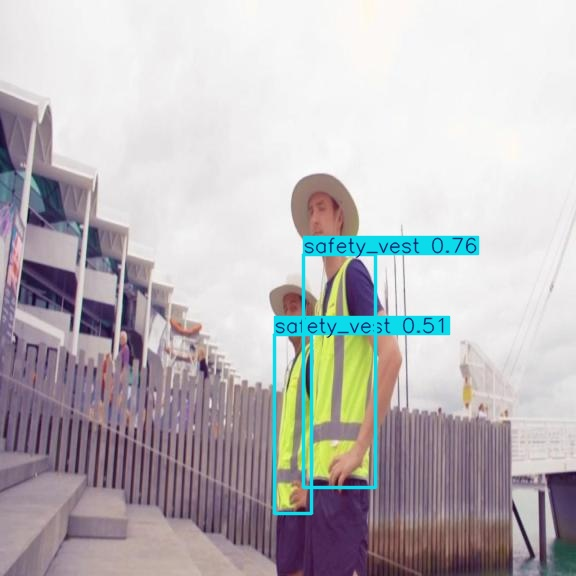

In [64]:
import glob
import os
from IPython.display import Image as IPyImage, display

prediction_folders = glob.glob("/content/runs/detect/predict*")

if prediction_folders:
    latest_folder = max(prediction_folders, key=os.path.getmtime)
    for img in glob.glob(f"{latest_folder}/*.jpg")[1:4]:
        display(IPyImage(filename=img, width=600))
        print("\n")
else:
    print("No prediction folders found in /content/runs/detect/. Please check if the YOLO prediction commands ran successfully.")

##Run Inference using YOLOv11 Model

In [65]:
import glob

# Find the first image in the test set to use for prediction
test_image_path = glob.glob(f"{dataset.location}/test/images/*")[0]
print(f"Using image for prediction: {test_image_path}")

!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" conf=0.25 source="{test_image_path}" save=True

Using image for prediction: /content/Safety-Vests-14/test/images/pos_1742_jpg.rf.d20915c6d5ec6145acf0b237f8e697cd.jpg
Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/Safety-Vests-14/test/images/pos_1742_jpg.rf.d20915c6d5ec6145acf0b237f8e697cd.jpg: 640x640 1 safety_vest, 9.7ms
Speed: 4.5ms preprocess, 9.7ms inference, 15.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [66]:
import os
import glob
from IPython.display import Image

# Assuming test_image_path holds the original image path
# This variable is available from cell 4cef8mmv5-Rj
predicted_image_name = os.path.basename(test_image_path)

# Find the latest prediction folder (e.g., predict, predict2, predict3)
prediction_folders = glob.glob("/content/runs/detect/predict*")
if prediction_folders:
    latest_prediction_folder = max(prediction_folders, key=os.path.getmtime)
    predicted_image_path = os.path.join(latest_prediction_folder, predicted_image_name)
    Image(predicted_image_path, width=600)
else:
    print("No prediction folders found. Please ensure the YOLO prediction command ran successfully.")

In [67]:
!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" source="/content/videoplayback.avi" conf=0.25 save=True

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 986, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 536, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/predictor.py", line 244, in predict_cli
    for _ in gen:  # sourcery skip: remove-empty-nested-block, noqa
             ^^^
  File "/usr/local/lib/python3.12

It appears the video file `/content/videoplayback.avi` is missing. Please upload your video file to the Colab environment or provide the correct path to an existing video file.

In [68]:
# After uploading, update the 'video_path' variable with the correct path to your video file.
video_path = '/content/your_uploaded_video.mp4' # Replace with the actual path to your video file

!yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" source="{video_path}" conf=0.25 save=True

Ultralytics 8.4.25 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 986, in entrypoint
    getattr(model, mode)(**overrides)  # default args from model
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 536, in predict
    return self.predictor.predict_cli(source=source) if is_cli else self.predictor(source=source, stream=stream)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/predictor.py", line 244, in predict_cli
    for _ in gen:  # sourcery skip: remove-empty-nested-block, noqa
             ^^^
  File "/usr/local/lib/python3.12

##Compress and Display YOLOv11 Inference Video

In [69]:
import os
from IPython.display import Video

save_path = "/content/runs/detect/predict3/videoplayback.avi"
compress_path = "/content/videoplayback.mp4"

os.system(f"ffmpeg -y -i {save_path} -vcodec libx264 -acodec aac {compress_path}")

Video(compress_path, embed=True)


In [70]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 138.8 MB/s eta 0:00:00


##Zip and Download YOLOv11 Results Folder via Streamlit

In [71]:
import streamlit as st
import zipfile
import os
from io import BytesIO

def zip_folder(folder_path):
    zip_buffer = BytesIO()
    with zipfile.ZipFile(zip_buffer, "w", zipfile.ZIP_DEFLATED, compresslevel=9) as zip_file:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, start=folder_path)
                zip_file.write(file_path, arcname)
    zip_buffer.seek(0)
    return zip_buffer

folder_to_zip = "/content/runs"

if os.path.exists(folder_to_zip):
    zipped_folder = zip_folder(folder_to_zip)

    st.success("✅ Folder zipped successfully!")

    st.download_button(
        label="📦 Download Results Folder",
        data=zipped_folder,
        file_name="runs.zip",
        mime="application/zip"
    )
else:
    st.warning(f"⚠ Folder '{folder_to_zip}' not found.")


2026-03-23 18:16:45.793 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 18:16:45.891 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-23 18:16:45.892 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 18:16:45.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 18:16:45.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 18:16:45.896 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 18:16:45.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 18:16:45.898 Thread 'MainThread': mi

In [72]:
model.save('yolo11n_safety_vest_model.pt')
print("Model saved as 'yolo11n_safety_vest_model.pt'")

Model saved as 'yolo11n_safety_vest_model.pt'


You can save the trained model using the `model.save()` method. The `train` method automatically saves the `best.pt` and `last.pt` weights in the `runs/detect/train/weights/` directory.

In [73]:
from google.colab import files
import os

# Define the directory where the weights are saved
weights_dir = '/content/runs/detect/train/weights/'

# Define the file names to download
files_to_download = ['best.pt', 'last.pt']

for filename in files_to_download:
    file_path = os.path.join(weights_dir, filename)
    if os.path.exists(file_path):
        try:
            files.download(file_path)
            print(f"Successfully initiated download for '{filename}'")
        except Exception as e:
            print(f"Error downloading '{filename}': {e}")
    else:
        print(f"Error: File '{filename}' not found at '{file_path}'. Please ensure training completed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully initiated download for 'best.pt'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully initiated download for 'last.pt'


In [74]:
from google.colab import files

# Path to the saved model file
model_file_path = 'yolo11n_safety_vest_model.pt'

# Download the model file
try:
    files.download(model_file_path)
    print(f"Successfully initiated download for '{model_file_path}'")
except FileNotFoundError:
    print(f"Error: Model file '{model_file_path}' not found. Please ensure the model was saved correctly.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully initiated download for 'yolo11n_safety_vest_model.pt'


In [75]:
!ls /content/runs/detect/train2/weights


best.pt  last.pt


In [76]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [77]:
!cp /content/runs/detect/train2/weights/best.pt /content/drive/MyDrive/best.pt


In [78]:
from google.colab import files
files.download('/content/runs/detect/train2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>